# 04 - Model Training: CNN Transfer Learning & Experimental Design
**Diabetic Retinopathy Stage Detection**

Rubric criteria 4 (architecture + transfer learning, 20 marks) and 5 (training strategy, 10 marks).

Experimental design - every question answered with a controlled comparison on the **validation** set
(the test set is touched only once, in notebook 05):

| # | Question | Runs |
|---|---|---|
| E0 | Is transfer learning needed at all? | small CNN from scratch |
| E1 | Which imbalance remedy works best? | EfficientNet-B0 x {none, class weights, sqrt oversampling} |
| E2 | Which backbone? | {EfficientNet-B0, ResNet50-V2, DenseNet-121} with the E1 winner |
| E3 | Hyper-parameters | fine-tune LR and dropout sweep on the E2 winner |
| E4 | Final model | E2/E3 winner, long two-phase schedule with early stopping |

Training strategy (all runs): two-phase transfer learning (frozen backbone -> partial unfreeze with
BatchNorm frozen), Adam, on-the-fly augmentation, `ModelCheckpoint` on val QWK, `EarlyStopping`,
`ReduceLROnPlateau`, CSV logging, mixed-precision on GPU. All logic in `src/model.py` and `src/train.py`.

In [1]:
# --- Environment bootstrap: works on Kaggle, Ubuntu GPU box and Windows ----
import os, sys, subprocess
from pathlib import Path

REPO = "https://github.com/pradeesha999/dr-stage-detection-v2.git"
if Path("/kaggle/working").exists():
    dst = Path("/kaggle/working/dr_project")
    if not dst.exists():
        try:   # private repo: store a GitHub token as Kaggle secret GITHUB_TOKEN
            from kaggle_secrets import UserSecretsClient
            url = REPO.replace("https://", f"https://{UserSecretsClient().get_secret('GITHUB_TOKEN')}@")
        except Exception:
            url = REPO                      # works as-is if the repo is public
        subprocess.run(["git", "clone", "-q", url, str(dst)], check=True)
        subprocess.run(["git", "-C", str(dst), "remote", "set-url", "origin", REPO])  # keep token out of .git/config
    os.chdir(dst / "notebooks")
sys.path.insert(0, str(Path.cwd().parent))     # notebooks/ -> dr_project/
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf, keras

from src import config, data, utils, dataset, train
from src import model as M
utils.set_seed()
sns.set_theme(style="whitegrid")

gpus = tf.config.list_physical_devices("GPU")
print("TF", tf.__version__, "| Keras", keras.__version__, "| GPUs:", gpus)
if gpus:
    keras.mixed_precision.set_global_policy("mixed_float16")   # ~2x faster on T4 tensor cores
    print("mixed precision ON")

train_df, val_df, test_df = data.load_splits()
assert Path(train_df.proc_path.iloc[0]).exists(), "run 02_preprocessing first (processed cache missing)"
print(len(train_df), len(val_df), len(test_df))

# QUICK=True -> tiny subset + 1 epoch per phase, just to check the notebook runs end-to-end.
QUICK = os.environ.get("DR_QUICK", "0") == "1"
if QUICK:
    train_df = train_df.groupby("label").head(60); val_df = val_df.groupby("label").head(30)
E = (lambda n: 1) if QUICK else (lambda n: n)      # epoch scaler
print("QUICK mode:", QUICK)

TF 2.20.0 | Keras 3.13.2 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
mixed precision ON
24588 5268 5270
QUICK mode: False


## E0 - Baseline: small CNN trained from scratch

In [2]:
r = train.run_experiment("E0_baseline_cnn", train_df, val_df, baseline_cnn=True,
                         balancing="class_weights", epochs_head=E(8), epochs_finetune=0,
                         lr_head=1e-3, patience=4, notes="from scratch, no pretrained weights")

I0000 00:00:1789908552.632335     435 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789908552.634916     435 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



[E0_baseline_cnn] phase 1 (frozen backbone): lr=0.001 epochs=8 params={'trainable': 422917, 'non_trainable': 960, 'total': 423877}
Epoch 1/8


2026-09-20 12:49:33.107810: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv (f16[128,3,3,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,56,56,64]{3,2,1,0}, f16[32,56,56,128]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-20 12:49:33.223667: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.115952854s
Trying algorithm eng19{k2=0} for conv (f16[128,3,3,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,56,56,64]{3,2,1,0}, f16[32,56,56,128]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"oper

   val_macro_f1=0.0286  val_qwk=0.0036
769/769 - 261s - 339ms/step - accuracy: 0.1865 - loss: 1.6771 - val_accuracy: 0.0306 - val_loss: 1.6717 - val_macro_f1: 0.0286 - val_qwk: 0.0036 - learning_rate: 0.0010
Epoch 2/8
   val_macro_f1=0.0613  val_qwk=0.0021
769/769 - 226s - 293ms/step - accuracy: 0.1770 - loss: 1.6212 - val_accuracy: 0.1044 - val_loss: 1.6495 - val_macro_f1: 0.0613 - val_qwk: 0.0021 - learning_rate: 0.0010
Epoch 3/8
   val_macro_f1=0.0656  val_qwk=0.0477
769/769 - 223s - 290ms/step - accuracy: 0.1633 - loss: 1.6090 - val_accuracy: 0.0797 - val_loss: 1.4780 - val_macro_f1: 0.0656 - val_qwk: 0.0477 - learning_rate: 0.0010
Epoch 4/8
   val_macro_f1=0.1037  val_qwk=0.0450
769/769 - 221s - 288ms/step - accuracy: 0.2024 - loss: 1.5890 - val_accuracy: 0.1222 - val_loss: 1.6208 - val_macro_f1: 0.1037 - val_qwk: 0.0450 - learning_rate: 0.0010
Epoch 5/8
   val_macro_f1=0.0178  val_qwk=0.0057

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
769/769 - 22

## E1 - Class-imbalance strategy (EfficientNet-B0)
Same backbone, same schedule, only the balancing changes. Compared on **macro-F1** and **QWK**
(accuracy is dominated by No_DR and would reward ignoring the minority stages).

In [3]:
for bal in ["none", "class_weights", "sqrt"]:
    train.run_experiment(f"E1_effb0_{bal}", train_df, val_df, backbone="efficientnetb0",
                         balancing=bal, epochs_head=E(3), epochs_finetune=E(4), patience=3,
                         notes="imbalance ablation")
e1 = train.results_table(); e1 = e1[e1.run.str.startswith("E1")]
display(e1)
BEST_BAL = e1.iloc[0].balancing
print("-> best balancing:", BEST_BAL)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

[E1_effb0_none] phase 1 (frozen backbone): lr=0.001 epochs=3 params={'trainable': 329221, 'non_trainable': 4049571, 'total': 4378792}
Epoch 1/3
   val_macro_f1=0.2931  val_qwk=0.3024
769/769 - 423s - 550ms/step - accuracy: 0.7334 - loss: 0.8237 - val_accuracy: 0.7339 - val_loss: 0.8830 - val_macro_f1: 0.2931 - val_qwk: 0.3024 - learning_rate: 0.0010
Epoch 2/3
   val_macro_f1=0.2427  val_qwk=0.1186
769/769 - 223s - 290ms/step - accuracy: 0.7395 - loss: 0.7930 - val_accuracy: 0.7384 - val_loss: 0.7686 - val_macro_f1: 0.2427 - val_qwk: 0.1186 - learning_rate: 0.0010
Epoch 3/3
   val_macro_f1=0.2618  val_qwk=0.1627
769/769 - 226s - 294ms/step - accuracy: 0.7397 - loss: 0.7839 - val_accuracy: 0.7401 - val_loss: 0.7665 - val_macro_f1: 0.2618 - val_qwk: 0.1627 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.
unfroze 57 backbone layers (top 30%)

[E1_effb0_none] phase 2 (fine-tune): lr=0.0001 epochs=4 params=

2026-09-20 13:34:41.846559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 13:34:41.992254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 13:34:42.170296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 13:34:42.344031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 13:39:11.939358: E external/local_xla/xla/stream_

   val_macro_f1=0.3558  val_qwk=0.3772
769/769 - 426s - 554ms/step - accuracy: 0.7441 - loss: 0.7722 - val_accuracy: 0.7485 - val_loss: 0.7386 - val_macro_f1: 0.3558 - val_qwk: 0.3772 - learning_rate: 1.0000e-04
Epoch 2/4
   val_macro_f1=0.2596  val_qwk=0.1886
769/769 - 228s - 296ms/step - accuracy: 0.7509 - loss: 0.7381 - val_accuracy: 0.7413 - val_loss: 0.8308 - val_macro_f1: 0.2596 - val_qwk: 0.1886 - learning_rate: 1.0000e-04
Epoch 3/4
   val_macro_f1=0.3742  val_qwk=0.4449
769/769 - 227s - 295ms/step - accuracy: 0.7565 - loss: 0.7161 - val_accuracy: 0.7555 - val_loss: 0.7228 - val_macro_f1: 0.3742 - val_qwk: 0.4449 - learning_rate: 1.0000e-04
Epoch 4/4
   val_macro_f1=0.3640  val_qwk=0.4037
769/769 - 225s - 293ms/step - accuracy: 0.7616 - loss: 0.7018 - val_accuracy: 0.7536 - val_loss: 0.7295 - val_macro_f1: 0.3640 - val_qwk: 0.4037 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 3.

[E1_effb0_none] done in 33.0 min | acc=0.7555 macroF1=0.3742 Q

,run,backbone,balancing,img_size,epochs_run,params_M,val_accuracy,val_macro_f1,val_qwk,minutes,notes
0,E1_effb0_sqrt,efficientnetb0,sqrt,224,7,4.4,0.739560,0.399338,0.511832,30.9,imbalance ablation
1,E1_effb0_none,efficientnetb0,none,224,7,4.4,0.755505,0.374180,0.444902,33.0,imbalance ablation
2,E1_effb0_class_weights,efficientnetb0,class_weights,224,7,4.4,0.438686,0.289588,0.366717,32.6,imbalance ablation


-> best balancing: sqrt


## E2 - Backbone comparison (with the best balancing strategy)

In [4]:
for bb in ["efficientnetb0", "resnet50v2", "densenet121"]:
    train.run_experiment(f"E2_{bb}", train_df, val_df, backbone=bb, balancing=BEST_BAL,
                         epochs_head=E(3), epochs_finetune=E(5), patience=3, notes="backbone comparison")
e2 = train.results_table(); e2 = e2[e2.run.str.startswith("E2")]
display(e2)
BEST_BB = e2.iloc[0].backbone
print("-> best backbone:", BEST_BB)


[E2_efficientnetb0] phase 1 (frozen backbone): lr=0.001 epochs=3 params={'trainable': 329221, 'non_trainable': 4049571, 'total': 4378792}
Epoch 1/3
   val_macro_f1=0.3143  val_qwk=0.3955
768/768 - 342s - 445ms/step - accuracy: 0.5093 - loss: 1.2266 - val_accuracy: 0.7043 - val_loss: 0.9841 - val_macro_f1: 0.3143 - val_qwk: 0.3955 - learning_rate: 0.0010
Epoch 2/3
   val_macro_f1=0.3284  val_qwk=0.3938
768/768 - 224s - 292ms/step - accuracy: 0.5325 - loss: 1.1586 - val_accuracy: 0.7274 - val_loss: 0.9180 - val_macro_f1: 0.3284 - val_qwk: 0.3938 - learning_rate: 0.0010
Epoch 3/3
   val_macro_f1=0.3458  val_qwk=0.4091
768/768 - 228s - 297ms/step - accuracy: 0.5329 - loss: 1.1513 - val_accuracy: 0.7363 - val_loss: 0.8868 - val_macro_f1: 0.3458 - val_qwk: 0.4091 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
unfroze 57 backbone layers (top 30%)

[E2_efficientnetb0] phase 2 (fine-tune): lr=0.0001 epochs=5 params={'trainable': 3383841, 'non_trainable': 994

,run,backbone,balancing,img_size,epochs_run,params_M,val_accuracy,val_macro_f1,val_qwk,minutes,notes
0,E2_resnet50v2,resnet50v2,sqrt,224,8,24.1,0.738421,0.419316,0.536282,31.9,backbone comparison
1,E2_densenet121,densenet121,sqrt,224,8,7.3,0.757024,0.407521,0.529880,34.4,backbone comparison
2,E2_efficientnetb0,efficientnetb0,sqrt,224,8,4.4,0.732156,0.414394,0.525530,34.5,backbone comparison


-> best backbone: resnet50v2


## E3 - Hyper-parameter tuning on the winner (fine-tune LR x dropout)

In [5]:
for lr_ft, dr in [(3e-5, 0.3), (1e-4, 0.5), (3e-4, 0.3)]:
    train.run_experiment(f"E3_{BEST_BB}_lr{lr_ft:g}_do{dr}", train_df, val_df, backbone=BEST_BB,
                         balancing=BEST_BAL, epochs_head=E(2), epochs_finetune=E(4), patience=3,
                         lr_finetune=lr_ft, dropout=dr, notes="hparam sweep")
e3 = train.results_table(); e3 = e3[e3.run.str.startswith(("E2_" + BEST_BB, "E3"))]
display(e3)
best = e3.iloc[0]
cfg = json.loads((train.METRIC_DIR / f"{best.run}.json").read_text())
LR_FT, DROPOUT = cfg["lr_finetune"], cfg["dropout"]
print(f"-> best fine-tune lr={LR_FT}, dropout={DROPOUT}")


[E3_resnet50v2_lr3e-05_do0.3] phase 1 (frozen backbone): lr=0.001 epochs=2 params={'trainable': 525829, 'non_trainable': 23564800, 'total': 24090629}
Epoch 1/2
   val_macro_f1=0.2589  val_qwk=0.2350
768/768 - 261s - 340ms/step - accuracy: 0.4908 - loss: 1.2967 - val_accuracy: 0.7352 - val_loss: 0.9544 - val_macro_f1: 0.2589 - val_qwk: 0.2350 - learning_rate: 0.0010
Epoch 2/2
   val_macro_f1=0.2718  val_qwk=0.3042
768/768 - 229s - 298ms/step - accuracy: 0.5168 - loss: 1.2183 - val_accuracy: 0.7284 - val_loss: 0.9112 - val_macro_f1: 0.2718 - val_qwk: 0.3042 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.
unfroze 42 backbone layers (top 30%)

[E3_resnet50v2_lr3e-05_do0.3] phase 2 (fine-tune): lr=3e-05 epochs=4 params={'trainable': 17706501, 'non_trainable': 6384128, 'total': 24090629}
Epoch 1/4
   val_macro_f1=0.3366  val_qwk=0.3832
768/768 - 270s - 352ms/step - accuracy: 0.5337 - loss: 1.1554 - val_accuracy: 0.7453 - val_loss: 0.8229 - val_macro_f1: 0.

,run,backbone,balancing,img_size,epochs_run,params_M,val_accuracy,val_macro_f1,val_qwk,minutes,notes
0,E2_resnet50v2,resnet50v2,sqrt,224,8,24.1,0.738421,0.419316,0.536282,31.9,backbone comparison
3,E3_resnet50v2_lr0.0001_do0.5,resnet50v2,sqrt,224,6,24.1,0.744305,0.406742,0.515417,24.3,hparam sweep
4,E3_resnet50v2_lr0.0003_do0.3,resnet50v2,sqrt,224,6,24.1,0.742027,0.419780,0.512988,24.5,hparam sweep
6,E3_resnet50v2_lr3e-05_do0.3,resnet50v2,sqrt,224,6,24.1,0.735573,0.399990,0.498766,24.4,hparam sweep


-> best fine-tune lr=0.0001, dropout=0.3


## E4 - Final model: long two-phase schedule with early stopping
Head for 5 epochs at 1e-3, then top 30 % of the backbone unfrozen for up to 25 epochs
(early stopping, patience 6, on validation QWK). Label smoothing 0.1 for calibration.

In [6]:
final = train.run_experiment("E4_final", train_df, val_df, backbone=BEST_BB, balancing=BEST_BAL,
                             epochs_head=E(5), epochs_finetune=E(25), patience=6,
                             lr_finetune=LR_FT, dropout=DROPOUT, label_smoothing=0.1,
                             notes="final model")
(train.METRIC_DIR / "final_run.txt").write_text("E4_final")


[E4_final] phase 1 (frozen backbone): lr=0.001 epochs=5 params={'trainable': 525829, 'non_trainable': 23564800, 'total': 24090629}
Epoch 1/5
   val_macro_f1=0.2730  val_qwk=0.2285
768/768 - 263s - 342ms/step - accuracy: 0.4908 - loss: 1.3655 - val_accuracy: 0.7373 - val_loss: 1.0654 - val_macro_f1: 0.2730 - val_qwk: 0.2285 - learning_rate: 0.0010
Epoch 2/5
   val_macro_f1=0.2974  val_qwk=0.3391
768/768 - 227s - 296ms/step - accuracy: 0.5148 - loss: 1.3050 - val_accuracy: 0.7312 - val_loss: 1.0829 - val_macro_f1: 0.2974 - val_qwk: 0.3391 - learning_rate: 0.0010
Epoch 3/5
   val_macro_f1=0.3045  val_qwk=0.2934

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
768/768 - 227s - 296ms/step - accuracy: 0.5130 - loss: 1.3032 - val_accuracy: 0.7369 - val_loss: 1.0660 - val_macro_f1: 0.3045 - val_qwk: 0.2934 - learning_rate: 0.0010
Epoch 4/5
   val_macro_f1=0.3121  val_qwk=0.3425
768/768 - 227s - 296ms/step - accuracy: 0.5168 - loss: 1.2925 - val_accuracy: 0.7346 - v

8

## Results: all experiments

,run,backbone,balancing,img_size,epochs_run,params_M,val_accuracy,val_macro_f1,val_qwk,minutes,notes
0,E4_final,resnet50v2,sqrt,224,19,24.1,0.737851,0.418674,0.541799,73.5,final model
1,E2_resnet50v2,resnet50v2,sqrt,224,8,24.1,0.738421,0.419316,0.536282,31.9,backbone comparison
2,E2_densenet121,densenet121,sqrt,224,8,7.3,0.757024,0.407521,0.529880,34.4,backbone comparison
3,E2_efficientnetb0,efficientnetb0,sqrt,224,8,4.4,0.732156,0.414394,0.525530,34.5,backbone comparison
4,E3_resnet50v2_lr0.0001_do0.5,resnet50v2,sqrt,224,6,24.1,0.744305,0.406742,0.515417,24.3,hparam sweep
5,E3_resnet50v2_lr0.0003_do0.3,resnet50v2,sqrt,224,6,24.1,0.742027,0.419780,0.512988,24.5,hparam sweep
6,E1_effb0_sqrt,efficientnetb0,sqrt,224,7,4.4,0.739560,0.399338,0.511832,30.9,imbalance ablation
7,E3_resnet50v2_lr3e-05_do0.3,resnet50v2,sqrt,224,6,24.1,0.735573,0.399990,0.498766,24.4,hparam sweep
8,E1_effb0_none,efficientnetb0,none,224,7,4.4,0.755505,0.374180,0.444902,33.0,imbalance ablation
9,E1_effb0_class_weights,efficientnetb0,class_weights,224,7,4.4,0.438686,0.289588,0.366717,32.6,imbalance ablation


saved /kaggle/working/dr_project/outputs/figures/04_experiment_summary.png


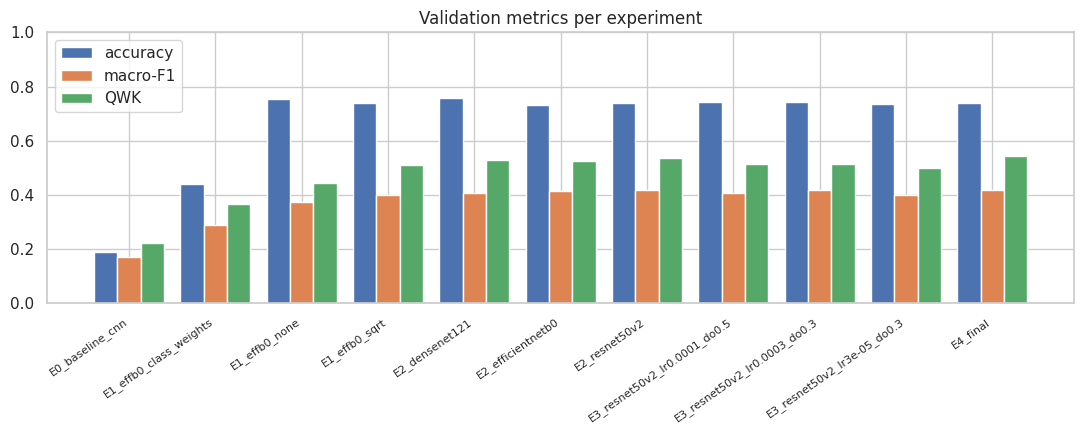

In [7]:
tbl = train.results_table()
tbl.to_csv(train.METRIC_DIR / "summary.csv", index=False)
display(tbl)

fig, ax = plt.subplots(figsize=(11, 4.5))
t = tbl.sort_values("run")
x = np.arange(len(t)); w = 0.27
ax.bar(x - w, t.val_accuracy, w, label="accuracy"); ax.bar(x, t.val_macro_f1, w, label="macro-F1"); ax.bar(x + w, t.val_qwk, w, label="QWK")
ax.set_xticks(x); ax.set_xticklabels(t.run, rotation=35, ha="right", fontsize=8); ax.set_ylim(0, 1); ax.legend()
ax.set_title("Validation metrics per experiment"); plt.tight_layout(); utils.save_fig("04_experiment_summary"); plt.show()

## Training curves (accuracy & loss) for the final model and the ablations

saved /kaggle/working/dr_project/outputs/figures/04_final_curves.png


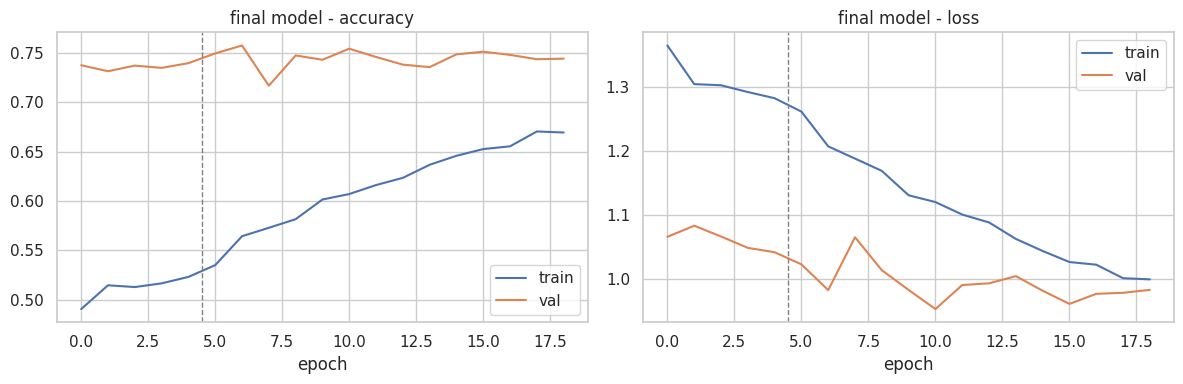

saved /kaggle/working/dr_project/outputs/figures/04_final_qwk_f1.png


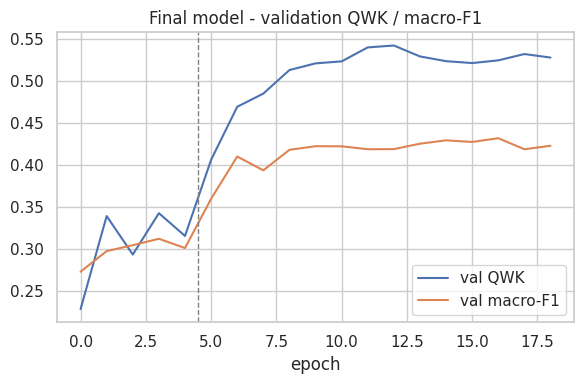

saved /kaggle/working/dr_project/outputs/figures/04_ablation_curves.png


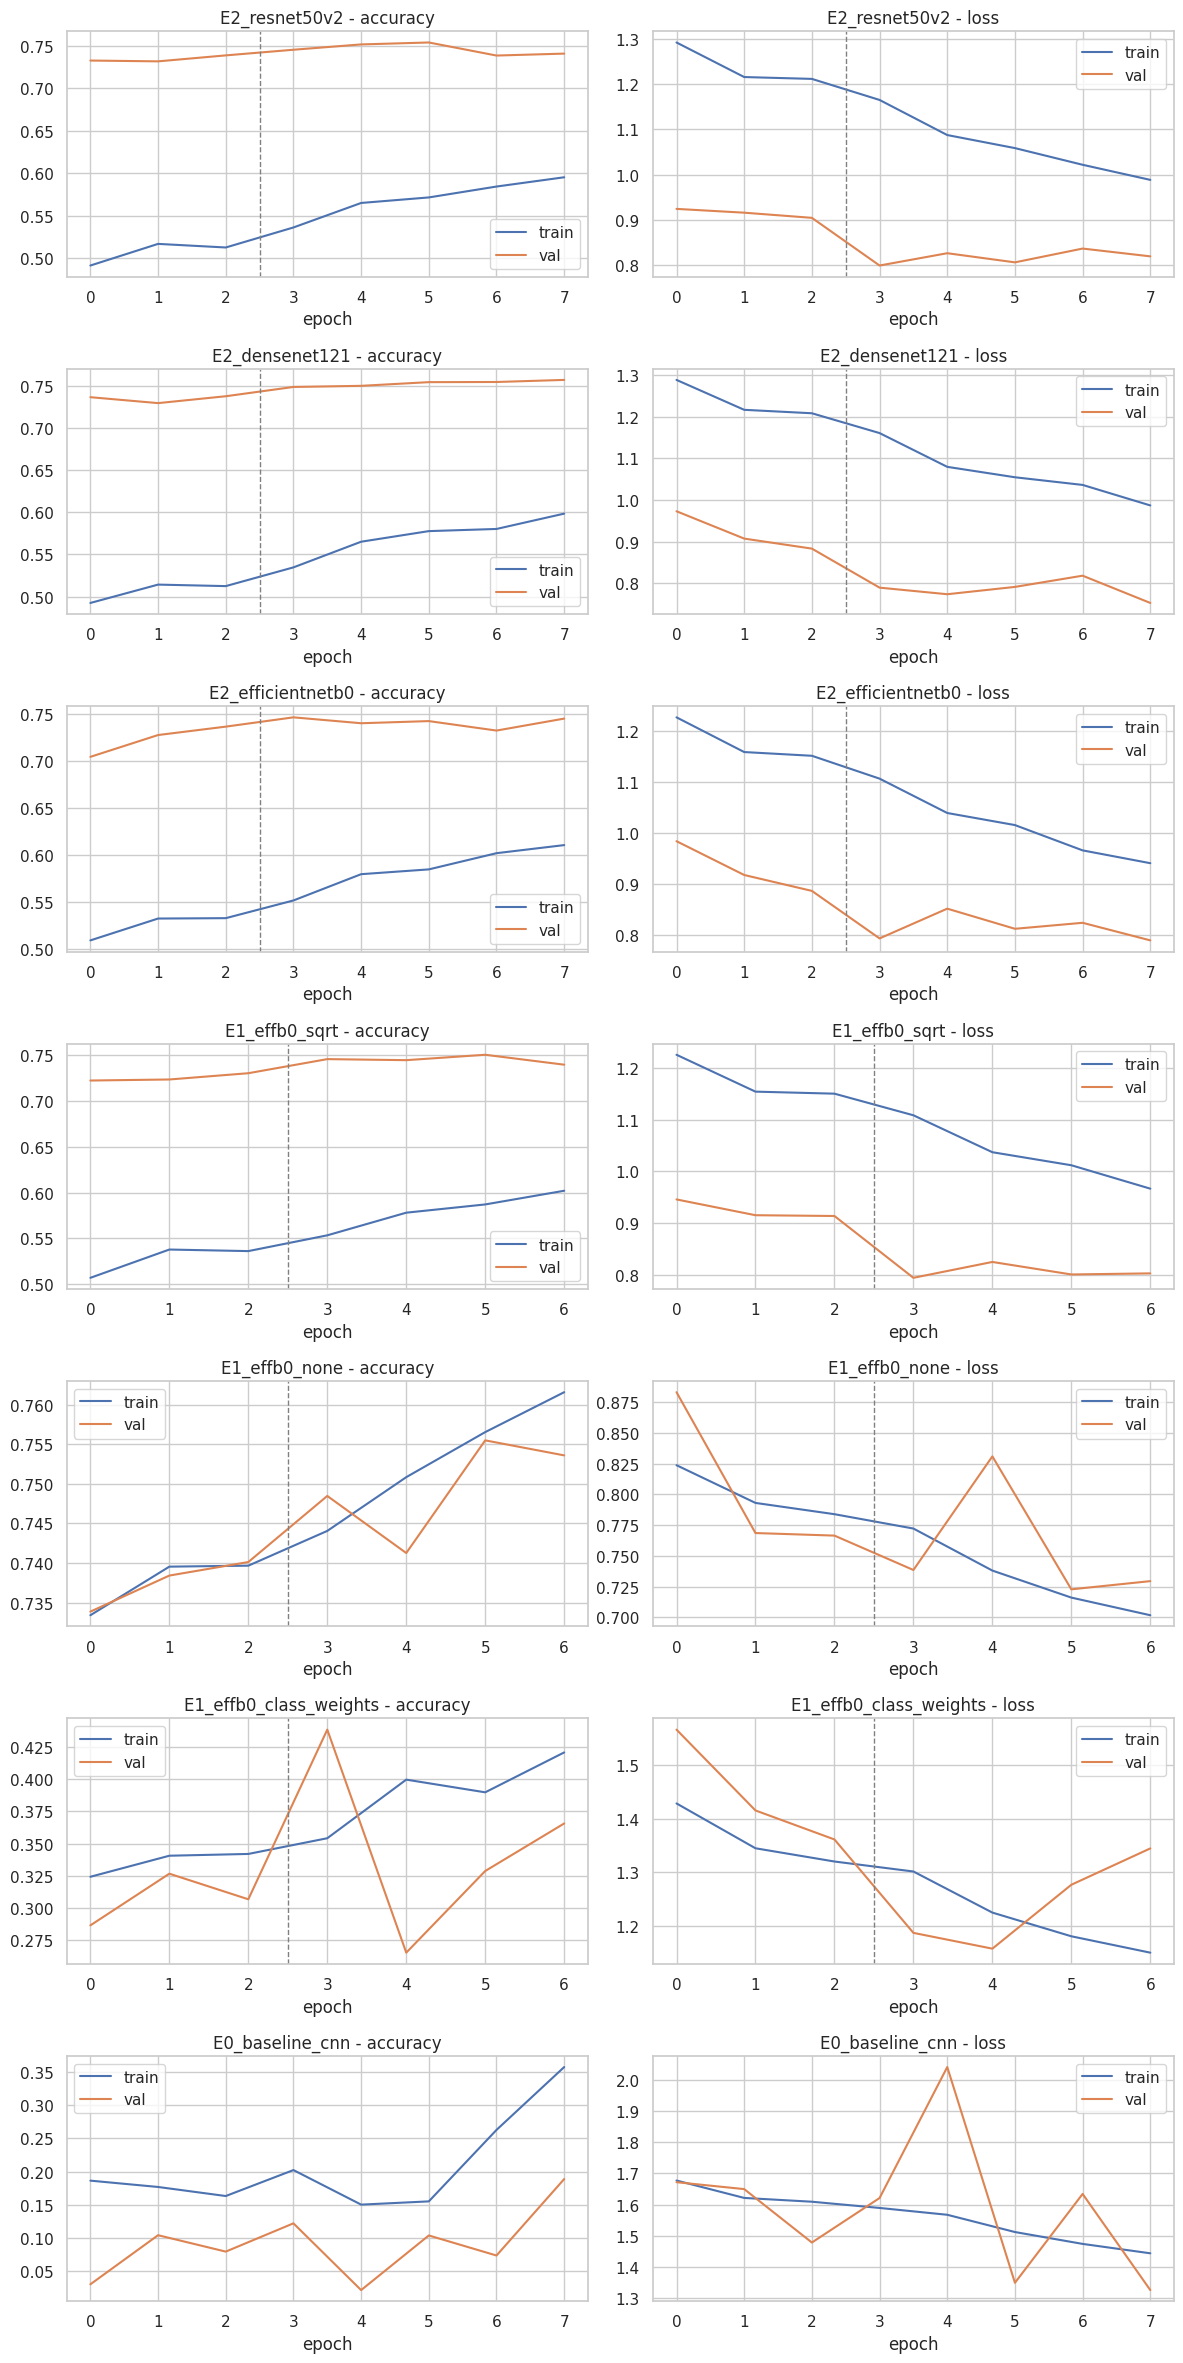

In [8]:
def plot_curves(run, ax_pair, title=None):
    h = train.load_curves(run)
    a1, a2 = ax_pair
    a1.plot(h.accuracy, label="train"); a1.plot(h.val_accuracy, label="val"); a1.set_title(f"{title or run} - accuracy"); a1.legend()
    a2.plot(h.loss, label="train"); a2.plot(h.val_loss, label="val"); a2.set_title(f"{title or run} - loss"); a2.legend()
    cfg = json.loads((train.METRIC_DIR / f"{run}.json").read_text())
    if cfg["epochs_head"] and cfg["epochs_finetune"]:
        for a in (a1, a2): a.axvline(cfg["epochs_head"] - 0.5, ls="--", c="gray", lw=1)
    a1.set_xlabel("epoch"); a2.set_xlabel("epoch")

fig, ax = plt.subplots(1, 2, figsize=(12, 4)); plot_curves("E4_final", ax, "final model")
plt.tight_layout(); utils.save_fig("04_final_curves"); plt.show()

# QWK / macro-F1 over epochs for the final model
h = train.load_curves("E4_final")
plt.figure(figsize=(6, 4)); plt.plot(h.val_qwk, label="val QWK"); plt.plot(h.val_macro_f1, label="val macro-F1")
plt.axvline(final["epochs_head"] - 0.5, ls="--", c="gray", lw=1); plt.xlabel("epoch"); plt.legend(); plt.title("Final model - validation QWK / macro-F1")
plt.tight_layout(); utils.save_fig("04_final_qwk_f1"); plt.show()

runs = [r for r in tbl.run if r.startswith(("E0", "E1", "E2"))]
fig, ax = plt.subplots(len(runs), 2, figsize=(12, 3.4 * len(runs)))
for i, r in enumerate(runs): plot_curves(r, ax[i])
plt.tight_layout(); utils.save_fig("04_ablation_curves"); plt.show()

## Notes for the report
* Dashed vertical line in the curves = switch from phase 1 (frozen backbone) to phase 2 (fine-tuning).
* `outputs/metrics/summary.csv` is the experiment table; `outputs/models/E4_final.keras` is the model
  evaluated in notebook 05.
* Everything is seeded (`SEED=42`), so re-running reproduces the numbers up to GPU non-determinism.